# 03. Análisis exploratorio

El análisis distingue el universo de 293 videos del subconjunto de 19 videos para los que se
recolectaron comentarios. Las asociaciones describen esta muestra; no se generalizan a YouTube ni
a la población de Guatemala.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Busca los CSV sin depender de una ruta absoluta del equipo
def localizar_archivo(nombre):
    candidatos = [
        Path.cwd() / nombre,
        Path.cwd() / "data" / nombre,
        Path.cwd().parent / "data" / nombre,
    ]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    buscadas = "\n- ".join(str(p) for p in candidatos)
    raise FileNotFoundError(
        f"No se encontró {nombre}. Colóquelo junto al notebook o en data/. "
        f"Rutas revisadas:\n- {buscadas}"
    )

RUTA_VIDEOS = localizar_archivo("youtube_videos.csv")
RUTA_COMENTARIOS = localizar_archivo("youtube_comments.csv")

ID_VIDEOS = {"video_id": "string", "channel_id": "string"}
ID_COMENTARIOS = {
    "video_id": "string",
    "comment_id": "string",
    "channel_id": "string",
    "author_channel_id": "string",
}

videos = pd.read_csv(RUTA_VIDEOS, dtype=ID_VIDEOS)
comentarios = pd.read_csv(RUTA_COMENTARIOS, dtype=ID_COMENTARIOS)

print(f"Videos: {videos.shape[0]:,} filas x {videos.shape[1]} columnas")
print(f"Comentarios: {comentarios.shape[0]:,} filas x {comentarios.shape[1]} columnas")
print(f"Archivos: {RUTA_VIDEOS.name}, {RUTA_COMENTARIOS.name}")


Videos: 293 filas x 20 columnas
Comentarios: 406 filas x 17 columnas
Archivos: youtube_videos.csv, youtube_comments.csv


In [ ]:
import re
import json
import unicodedata
from collections import Counter

STOPWORDS_ES = set("""
a al algo algunas algunos ante antes como con contra cual cuales cuando de del desde donde durante
e el ella ellas ellos en entre era eran eres es esa esas ese eso esos esta estaba estaban estado
estas este esto estos fue fueron ha han hasta hay la las le les lo los más me mi mis mucho muy no
nos o otra otro otras otros para pero poco por porque que quien quienes se ser si sin sobre son su
sus te tener tiene todo todos toda todas tu tus un una uno unos unas ya ni qué cómo cuál cuáles
cuándo cuánto cuánta cuántos cuántas dónde quién cuyo cuya cuyos cuyas aquel aquella aquellos
aquellas yo tú él nosotros ustedes usted mío mía tuyos tuyas nuestro nuestra también solo sólo cada
hacer hace hacía hacia menos aquí aqui ahí ahi allí alli pues entonces tan tanto nada nadie nunca siempre todavía
aun aún aunque sino mientras mismo misma mismos mismas vez veces puede pueden podría según tras
mas tambien está esta están estan tiene tienen
""".split())

URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
HASHTAG_RE = re.compile(r"(?<!\w)#([\wáéíóúüñ]+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"(?<!\w)@[\w.-]+", flags=re.IGNORECASE)
CUSTOM_EMOJI_RE = re.compile(r":[a-z0-9_-]+:", flags=re.IGNORECASE)
UNICODE_EMOJI_RE = re.compile(
    "[\U0001F1E6-\U0001FAFF\u2600-\u27BF]",
    flags=re.UNICODE,
)

# NKFC + recorte; conserva NA y no reemplaza IDs por etiquetas
def normalizar_texto_corto(serie):
    def uno(x):
        if pd.isna(x):
            return pd.NA
        return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(x)).strip())
    return serie.astype("string").map(uno)

def extraer_hashtags(texto):
    if pd.isna(texto):
        return []
    return [x.casefold() for x in HASHTAG_RE.findall(str(texto))]

def extraer_emojis(texto):
    if pd.isna(texto):
        return []
    texto = str(texto)
    return CUSTOM_EMOJI_RE.findall(texto) + UNICODE_EMOJI_RE.findall(texto)

# Versión analítica conservadora; el original siempre se guarda aparte
def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    s = unicodedata.normalize("NFKC", str(texto)).casefold()
    s = URL_RE.sub(" ", s)
    s = HASHTAG_RE.sub(r" \1 ", s) # #tema -> tema
    s = MENTION_RE.sub(" ", s) # elimina la etiqueta visible
    s = CUSTOM_EMOJI_RE.sub(" ", s)
    s = UNICODE_EMOJI_RE.sub(" ", s)
    s = re.sub(r"[^a-záéíóúüñ\s]", " ", s)  # también elimina números
    tokens = [t for t in s.split() if len(t) > 1 and t not in STOPWORDS_ES]
    return " ".join(tokens)

# Convierte conteos con separadores y sufijos k/m/mil/millón
def parsear_conteo_youtube(valor, vacio_como_cero=False):
    if pd.isna(valor) or not str(valor).strip():
        return 0 if vacio_como_cero else pd.NA
    s = unicodedata.normalize("NFKC", str(valor)).casefold().strip()
    s = re.sub(r"vistas?|likes?|me gusta", "", s).strip()
    multiplicador = 1
    if re.search(r"\b(k|mil)\b", s):
        multiplicador = 1_000
        s = re.sub(r"\b(k|mil)\b", "", s)
    elif re.search(r"\b(m|millones?|millón)\b", s):
        multiplicador = 1_000_000
        s = re.sub(r"\b(m|millones?|millón)\b", "", s)
    s = s.replace("\u00a0", "").replace(" ", "")
    if multiplicador == 1:
        s = re.sub(r"[,.]", "", s)
    else:
        s = s.replace(",", ".")
    try:
        return int(round(float(s) * multiplicador))
    except (TypeError, ValueError):
        return pd.NA


In [3]:
import matplotlib.pyplot as plt
from itertools import combinations

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_AZUL = "#1677B8"
COLOR_TURQUESA = "#00A6A6"
COLOR_NARANJA = "#F28E2B"

# Preprocesamiento mínimo, autocontenido y equivalente al notebook 02.
comentarios["like_count"] = comentarios["like_count_text"].map(
    lambda x: parsear_conteo_youtube(x, vacio_como_cero=True)
).astype("Int64")
comentarios["texto_original"] = comentarios["text"].astype("string").fillna("")
comentarios["texto_limpio"] = comentarios["texto_original"].map(limpiar_texto)
videos["texto_video_original"] = (
    videos["title"].astype("string").fillna("") + " " +
    videos["description"].astype("string").fillna("")
)

por_video = comentarios.groupby("video_id").agg(
    comentarios=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique"),
    respuestas=("reply_count", "sum"),
    me_gusta=("like_count", "sum"),
).reset_index()

participacion_video = videos[[
    "video_id", "title", "channel_id", "channel_name", "category", "source_query", "view_count"
]].merge(por_video, on="video_id", how="left", validate="one_to_one")
for col in ["comentarios", "autores_unicos", "respuestas", "me_gusta"]:
    participacion_video[col] = participacion_video[col].fillna(0).astype(int)


## 3.1 Descripción general


In [4]:
indicadores = pd.DataFrame({
    "indicador": ["videos", "canales", "comentarios", "autores únicos",
                  "videos con comentarios", "categorías", "consultas (videos)"],
    "valor": [len(videos), videos["channel_id"].nunique(), len(comentarios),
              comentarios["author_channel_id"].nunique(),
              comentarios["video_id"].nunique(), videos["category"].nunique(),
              videos["source_query"].nunique()],
})
indicadores


,indicador,valor
0,videos,293
1,canales,97
2,comentarios,406
3,autores únicos,332
4,videos con comentarios,19
5,categorías,11
6,consultas (videos),21


In [5]:
videos_por_canal = videos.groupby(["channel_id", "channel_name"]).size().rename("videos").sort_values(ascending=False)
resumen_numerico = pd.DataFrame({
    "videos_por_canal": videos_por_canal.describe(),
    "comentarios_por_video": participacion_video["comentarios"].describe(),
    "autores_por_video": participacion_video["autores_unicos"].describe(),
    "visualizaciones": videos["view_count"].describe(),
    "respuestas_por_comentario": comentarios["reply_count"].describe(),
    "me_gusta_por_comentario": comentarios["like_count"].astype(float).describe(),
})
resumen_numerico


,videos_por_canal,comentarios_por_video,autores_por_video,visualizaciones,respuestas_por_comentario,me_gusta_por_comentario
count,97.000,293.000,293.000,293.000,406.000,406.000
mean,3.021,1.386,1.171,"60,430.085",0.126,5.727
std,5.142,10.553,8.563,"515,798.306",0.581,30.661
min,1.000,0.000,0.000,2.000,0.000,0.000
25%,1.000,0.000,0.000,215.000,0.000,0.000
50%,1.000,0.000,0.000,"1,175.000",0.000,1.000
75%,2.000,0.000,0.000,"7,465.000",0.000,2.000
max,32.000,161.000,128.000,"8,190,449.000",7.000,405.000


In [6]:
top_videos = participacion_video.sort_values(
    ["comentarios", "autores_unicos"], ascending=False
).head(12)
top_videos[["video_id", "title", "channel_name", "comentarios", "autores_unicos", "view_count"]]


,video_id,title,channel_name,comentarios,autores_unicos,view_count
246,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128,11775
229,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,10156
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,32,11670
239,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,304089
136,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,19,3628
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,25,18,14200
289,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16,1954
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,14,13,6692
250,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10,717
197,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,PrensaLibreOficial,7,7,5469


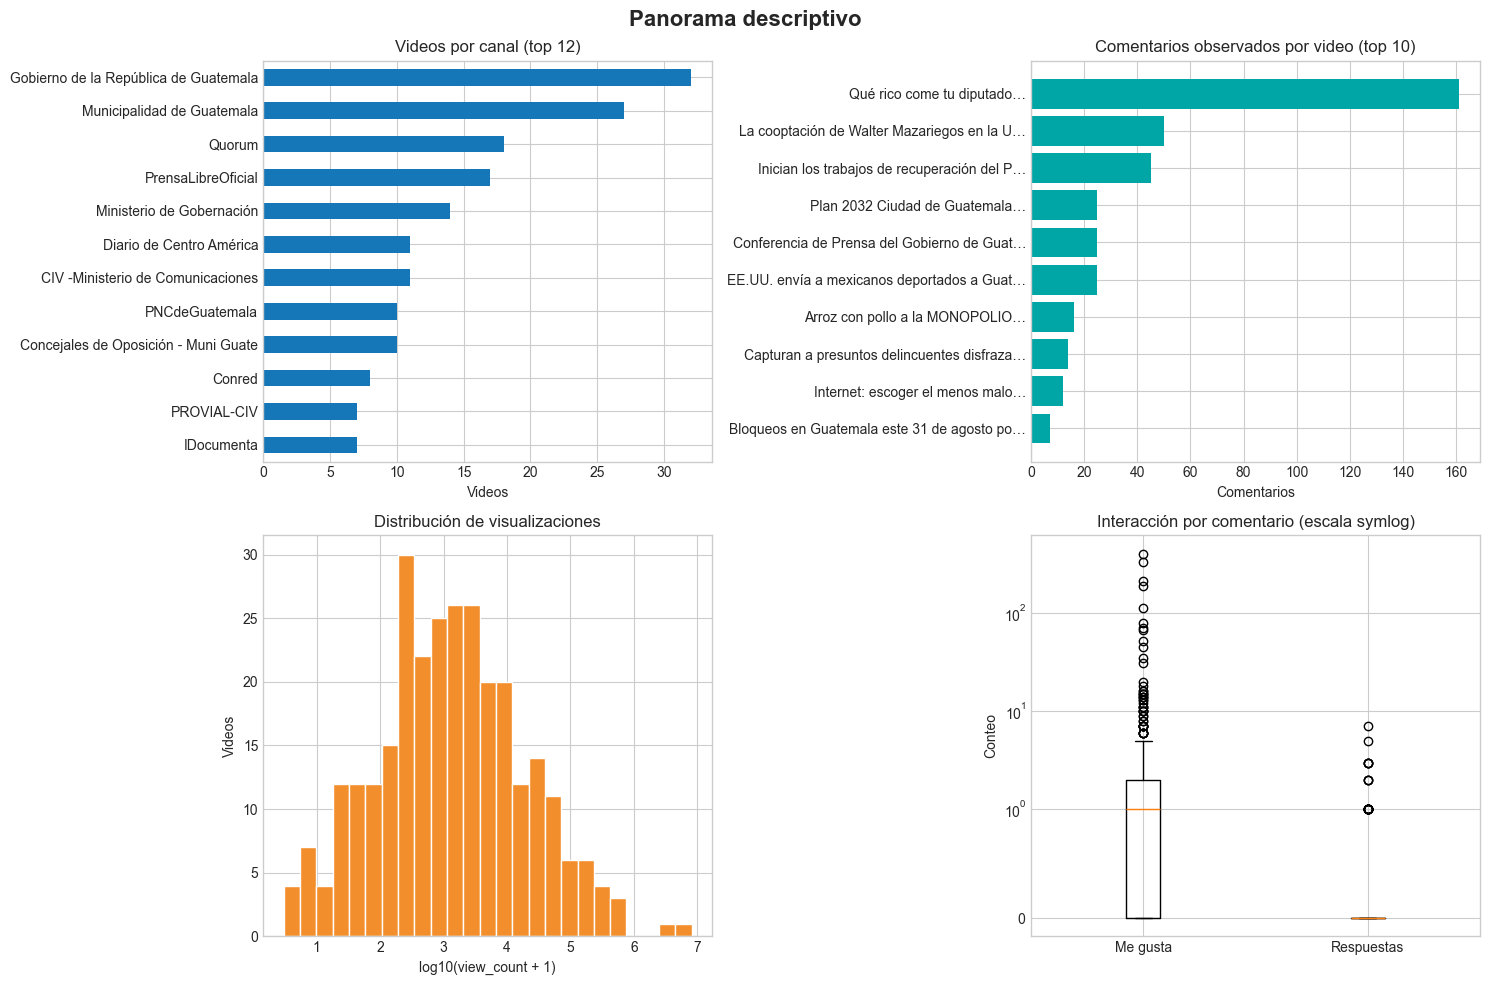

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

videos.groupby("channel_name").size().nlargest(12).sort_values().plot.barh(ax=axes[0,0], color=COLOR_AZUL)
axes[0,0].set_title("Videos por canal (top 12)")
axes[0,0].set_xlabel("Videos")
axes[0,0].set_ylabel("")

tv = top_videos.head(10).copy()
tv["etiqueta"] = tv["title"].str.slice(0, 42) + "…"
axes[0,1].barh(tv["etiqueta"][::-1], tv["comentarios"][::-1], color=COLOR_TURQUESA)
axes[0,1].set_title("Comentarios observados por video (top 10)")
axes[0,1].set_xlabel("Comentarios")

axes[1,0].hist(np.log10(videos["view_count"] + 1), bins=25, color=COLOR_NARANJA, edgecolor="white")
axes[1,0].set_title("Distribución de visualizaciones")
axes[1,0].set_xlabel("log10(view_count + 1)")
axes[1,0].set_ylabel("Videos")

datos_caja = [comentarios["like_count"].astype(float), comentarios["reply_count"].astype(float)]
axes[1,1].boxplot(datos_caja, tick_labels=["Me gusta", "Respuestas"], showfliers=True)
axes[1,1].set_yscale("symlog", linthresh=1)
axes[1,1].set_title("Interacción por comentario (escala symlog)")
axes[1,1].set_ylabel("Conteo")

fig.suptitle("Panorama descriptivo", fontsize=16, fontweight="bold")
plt.tight_layout()


In [8]:
categorias = videos["category"].value_counts().rename_axis("categoría").reset_index(name="videos")
consultas_videos = videos["source_query"].value_counts().head(15).rename_axis("consulta").reset_index(name="videos")
consultas_comentarios = comentarios["source_query"].value_counts().rename_axis("consulta").reset_index(name="comentarios")
print("Categorías")
print(categorias.to_string(index=False))
print("\nConsultas con más videos")
print(consultas_videos.to_string(index=False))
print("\nConsultas de los comentarios recolectados")
print(consultas_comentarios.to_string(index=False))


Categorías
            categoría  videos
      News & Politics     138
       People & Blogs      66
        Entertainment      48
            Education      19
      Travel & Events       8
 Science & Technology       6
Nonprofits & Activism       3
     Film & Animation       2
               Comedy       1
               Sports       1
                Music       1

Consultas con más videos
                              consulta  videos
            Municipalidad de Guatemala      20
       @GobiernodelaRepublicadeGuatema      18
                 Gobierno de Guatemala      18
                  @GobiernodeGuatemala      17
                    guatemala noticias      16
        @MunicipalidaddeGuatemala-1551      16
Ministerio de Comunicaciones Guatemala      16
                      Conred Guatemala      15
 Gobierno de la República de Guatemala      15
                         PMT Guatemala      15
                     guatemala trafico      13
                  guatemala transporte 

In [9]:
# Hashtags en títulos, descripciones y comentarios; palabras/bigramas en comentarios limpios.
corpus_original = pd.concat([
    videos["title"].fillna(""), videos["description"].fillna(""), comentarios["text"].fillna("")
], ignore_index=True)
hashtags = Counter(h for texto in corpus_original for h in extraer_hashtags(texto))
palabras = Counter(" ".join(comentarios["texto_limpio"]).split())
bigramas = Counter()
for texto in comentarios["texto_limpio"]:
    toks = texto.split()
    bigramas.update(zip(toks, toks[1:]))

top_palabras = pd.DataFrame(palabras.most_common(20), columns=["término", "frecuencia"])
top_bigramas = pd.DataFrame([(" ".join(k), n) for k, n in bigramas.most_common(20)],
                            columns=["bigrama", "frecuencia"])
top_hashtags = pd.DataFrame(hashtags.most_common(20), columns=["hashtag", "frecuencia"])

print("Palabras frecuentes")
print(top_palabras.to_string(index=False))
print("\nBigramas frecuentes")
print(top_bigramas.to_string(index=False))
print("\nHashtags frecuentes (todos los textos)")
print(top_hashtags.to_string(index=False))


Palabras frecuentes
   término  frecuencia
    pueblo          56
 guatemala          52
    dinero          34
presidente          32
      país          31
   trabajo          30
 diputados          28
 corruptos          24
  diputado          22
 excelente          21
     bueno          21
      pais          21
    sueldo          17
      dios          17
     ahora          16
      bien          14
       ver          14
     hacen          14
       van          14
  personas          13

Bigramas frecuentes
            bigrama  frecuencia
presidente bernardo           9
   bernardo arevalo           8
   ciudad guatemala           6
         nery rodas           5
            bla bla           5
    pacto corruptos           5
     viva guatemala           4
    busquen trabajo           4
        sería bueno           4
      paguen sueldo           4
         lleva años           4
      dinero pueblo           4
  guatemala saludos           4
    muriendo hambre         

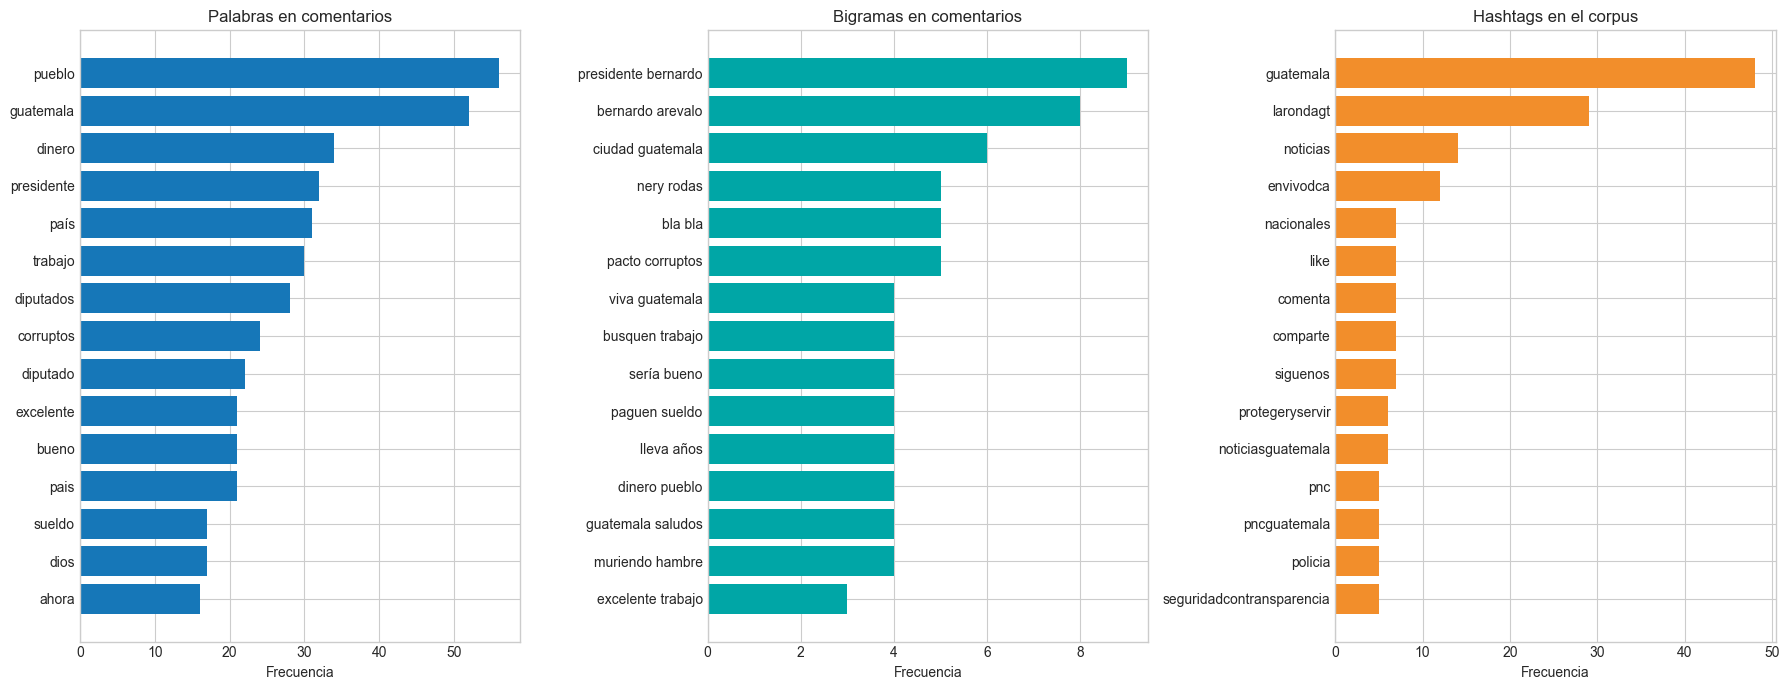

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, df, etiqueta, color, titulo in [
    (axes[0], top_palabras.head(15), "término", COLOR_AZUL, "Palabras en comentarios"),
    (axes[1], top_bigramas.head(15), "bigrama", COLOR_TURQUESA, "Bigramas en comentarios"),
    (axes[2], top_hashtags.head(15), "hashtag", COLOR_NARANJA, "Hashtags en el corpus"),
]:
    sub = df.head(15).iloc[::-1]
    ax.barh(sub[etiqueta], sub["frecuencia"], color=color)
    ax.set_title(titulo)
    ax.set_xlabel("Frecuencia")
plt.tight_layout()


## 3.2 Concentración de la participación

La concentración se calcula sobre los 406 comentarios observados. Se reportan cortes acumulados
para que la conclusión no dependa de elegir un único umbral arbitrario.


In [11]:
orden_video = participacion_video.sort_values("comentarios", ascending=False).reset_index(drop=True)
orden_video["comentarios_acumulados"] = orden_video["comentarios"].cumsum()
orden_video["proporción_acumulada"] = orden_video["comentarios_acumulados"] / len(comentarios)

comentarios_canal = comentarios.groupby(["channel_id", "channel_name"]).size().rename("comentarios").sort_values(ascending=False)
concentracion = []
for n in [1, 3, 5, 10]:
    concentracion.append({"unidad": "videos", "top_n": n,
                          "comentarios": int(orden_video.head(n)["comentarios"].sum()),
                          "proporción": orden_video.head(n)["comentarios"].sum()/len(comentarios)})
for n in [1, 3, 5]:
    concentracion.append({"unidad": "canales", "top_n": n,
                          "comentarios": int(comentarios_canal.head(n).sum()),
                          "proporción": comentarios_canal.head(n).sum()/len(comentarios)})
concentracion = pd.DataFrame(concentracion)
concentracion


,unidad,top_n,comentarios,proporción
0,videos,1,161,0.397
1,videos,3,256,0.631
2,videos,5,306,0.754
3,videos,10,380,0.936
4,canales,1,256,0.631
5,canales,3,351,0.865
6,canales,5,390,0.961


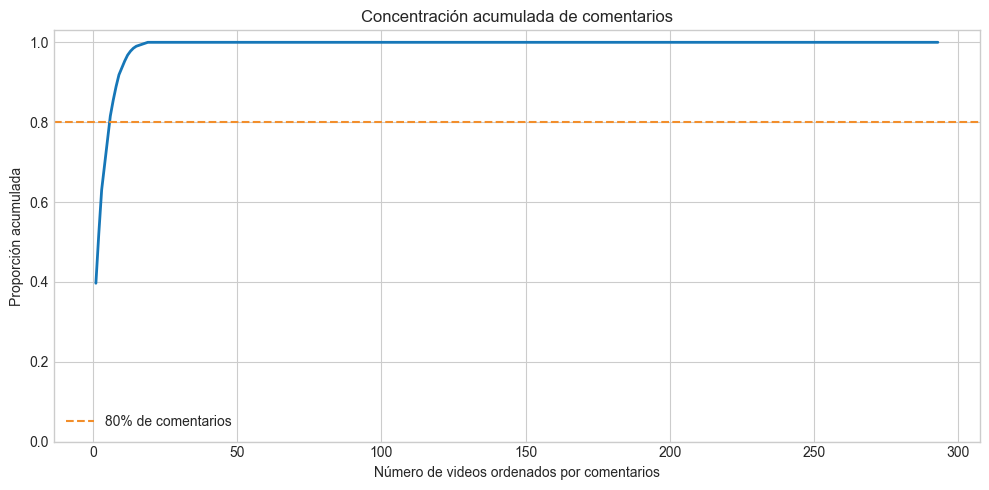

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, len(orden_video) + 1)
ax.plot(x, orden_video["proporción_acumulada"], color=COLOR_AZUL, linewidth=2)
ax.axhline(0.8, color=COLOR_NARANJA, linestyle="--", label="80% de comentarios")
ax.set_xlabel("Número de videos ordenados por comentarios")
ax.set_ylabel("Proporción acumulada")
ax.set_title("Concentración acumulada de comentarios")
ax.set_ylim(0, 1.03)
ax.legend()
plt.tight_layout()


## 3.3 Popularidad frente a participación

`view_count` es una instantánea de visualizaciones. El archivo de comentarios no es el total de
comentarios de cada video: contiene una selección recolectada. Por ello, correlación no significa
causalidad ni una tasa de participación real.


Spearman, 293 videos (incluye 274 ceros por falta de cobertura): 0.080
Spearman, solo 19 videos con comentarios recolectados: 0.811


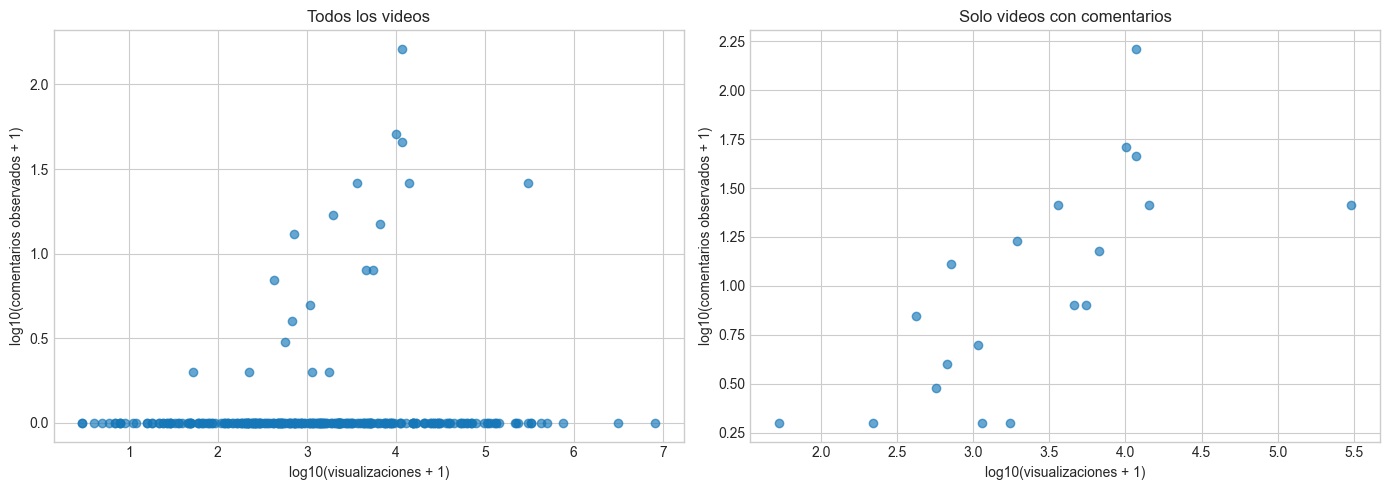

In [13]:
rho_todos = participacion_video["view_count"].rank().corr(participacion_video["comentarios"].rank())
con_comentarios = participacion_video[participacion_video["comentarios"] > 0].copy()
rho_cobertura = con_comentarios["view_count"].rank().corr(con_comentarios["comentarios"].rank())

print(f"Spearman, 293 videos (incluye 274 ceros por falta de cobertura): {rho_todos:.3f}")
print(f"Spearman, solo 19 videos con comentarios recolectados: {rho_cobertura:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, titulo in [
    (axes[0], participacion_video, "Todos los videos"),
    (axes[1], con_comentarios, "Solo videos con comentarios")
]:
    ax.scatter(np.log10(df["view_count"] + 1), np.log10(df["comentarios"] + 1),
               alpha=0.65, color=COLOR_AZUL)
    ax.set_xlabel("log10(visualizaciones + 1)")
    ax.set_ylabel("log10(comentarios observados + 1)")
    ax.set_title(titulo)
plt.tight_layout()


## 3.5 Audiencias compartidas, puentes y señales temáticas

Antes de construir formalmente la red, se cuentan autores repetidos entre videos/canales. Un
candidato a puente aquí significa **diversidad observada de participación**, no amistad,
influencia causal ni conversación directa.


In [14]:
def etiqueta_moda(s):
    modos = s.dropna().mode()
    return modos.iloc[0] if len(modos) else pd.NA

autores = comentarios.groupby("author_channel_id").agg(
    author_name=("author_name", etiqueta_moda),
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    canales=("channel_id", "nunique"),
).sort_values(["videos", "canales", "comentarios"], ascending=False)

autores_por_video = comentarios.groupby("video_id")["author_channel_id"].apply(set)
pares_video = []
titulos = videos.set_index("video_id")["title"].to_dict()
for a, b in combinations(autores_por_video.index, 2):
    compartidos = autores_por_video[a] & autores_por_video[b]
    if compartidos:
        pares_video.append({"video_a": a, "título_a": titulos[a], "video_b": b,
                            "título_b": titulos[b], "autores_compartidos": len(compartidos)})
pares_video = pd.DataFrame(pares_video).sort_values("autores_compartidos", ascending=False)

autores_por_canal = comentarios.groupby("channel_id")["author_channel_id"].apply(set)
nombres_canal = comentarios.groupby("channel_id")["channel_name"].agg(etiqueta_moda).to_dict()
pares_canal = []
for a, b in combinations(autores_por_canal.index, 2):
    n = len(autores_por_canal[a] & autores_por_canal[b])
    if n:
        pares_canal.append({"canal_a": nombres_canal[a], "canal_b": nombres_canal[b],
                            "autores_compartidos": n})
pares_canal = pd.DataFrame(pares_canal).sort_values("autores_compartidos", ascending=False)

print(f"Autores en más de un video: {(autores['videos'] > 1).sum()} de {len(autores)}")
print(f"Autores en más de un canal: {(autores['canales'] > 1).sum()} de {len(autores)}")
print(f"Pares de videos con audiencia compartida: {len(pares_video)}")
print(f"Pares de canales con audiencia compartida: {len(pares_canal)}")
print("\nCandidatos a puente por diversidad:")
print(autores.head(12).reset_index().to_string(index=False))
print("\nPares de videos con autores compartidos:")
print(pares_video.head(12).to_string(index=False))
print("\nPares de canales con autores compartidos:")
print(pares_canal.to_string(index=False))


Autores en más de un video: 9 de 332
Autores en más de un canal: 4 de 332
Pares de videos con audiencia compartida: 11
Pares de canales con audiencia compartida: 4

Candidatos a puente por diversidad:
       author_channel_id          author_name  comentarios  videos  canales
UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348            4       3        1
UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta            3       3        1
UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039            3       2        2
UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r            2       2        2
UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120            2       2        2
UCsUCN0Yq_UyTvKjOJLmNrnQ    @moisesvaldez4043            2       2        2
UCylqlpsh8ENNM1LqgQ1KbxA         @Jel.Awesh.M            3       2        1
UCbrtvygfRT6QXqWDNrOf-cA      @Alejandro00710            2       2        1
UCzZ6dDCEsLMXbc5pCFXIprw         @josegil3813            2       2        1
UCi2KiZq63sRq8Mfbcp-MelQ   @eugeneramir

In [15]:
# Señal exploratoria, no sustituto del análisis de sentimiento del punto 9.
LEX_POS = set("excelente bien bueno buena buenos buenas gracias apoyo viva bendiciones belleza felicidades correcto correcta mejor genial increíble maravilloso orgullo".split())
LEX_NEG = set("corrupto corruptos corrupción robo ladrón ladrones malo mala mal pena asco mentira mentiras odio problema problemas hambre inútil inútiles mediocre mediocres".split())

def señales_lexicas(serie):
    cnt = Counter(" ".join(serie).split())
    return pd.Series({"señales_positivas": sum(cnt[w] for w in LEX_POS),
                      "señales_negativas": sum(cnt[w] for w in LEX_NEG)})

señal_canal = comentarios.groupby("channel_name").filter(lambda x: len(x) >= 20).groupby("channel_name")["texto_limpio"].apply(señales_lexicas).unstack()
señal_canal["comentarios"] = comentarios["channel_name"].value_counts()
señal_canal.sort_values("comentarios", ascending=False)


,señales_positivas,señales_negativas,comentarios
channel_name,,,
Quorum,63,67,256
Gobierno de la República de Guatemala,24,10,70
Municipalidad de Guatemala,10,1,25
Noticias Telemundo,5,3,25


El conteo anterior solo identifica palabras indicativas de tono y no resuelve negación, ironía,
emojis ni contexto. La detección formal de comunidades corresponde al punto 7 y el análisis de
sentimiento al punto 9. Como descripción preliminar, Quorum concentra vocabulario sobre
`pueblo`, `dinero`, `diputados` y `corruptos`; los comentarios en canales gubernamentales se
concentran en `presidente`, `país`, `Guatemala`, `Arévalo`, `puente` y `gobierno`.


## Respuestas a las preguntas obligatorias (3.5)


In [ ]:
top_video = orden_video.iloc[0]
top_canal_idx = comentarios_canal.index[0]
repetidos = autores[autores["videos"] > 1]
comentarios_repetidos = comentarios[comentarios["author_channel_id"].isin(repetidos.index)].shape[0]

print("1) ¿Qué videos y canales concentran mayor participación?")
print(f"   El video '{top_video['title']}' ({top_video['channel_name']}) reúne {top_video['comentarios']} comentarios "
      f"({top_video['comentarios']/len(comentarios):.1%}). El canal {top_canal_idx[1]} reúne "
      f"{comentarios_canal.iloc[0]} ({comentarios_canal.iloc[0]/len(comentarios):.1%}).")

print("\n2) ¿Existen audiencias compartidas?")
print(f"   Sí, pero son escasas en la muestra: {len(pares_video)} pares de videos y {len(pares_canal)} pares de canales "
      "comparten al menos un autor. Solo 9 de 332 autores aparecen en varios videos.")

print("\n3) ¿Qué autores funcionan como puentes?")
print("   Son candidatos descriptivos quienes aparecen en varios videos/canales; la tabla anterior los identifica por ID. "
      f"Solo {(autores['canales'] > 1).sum()} autores cruzan canales. La intermediación formal se calculará en el punto 8.")

print("\n4) ¿Qué temas y sentimientos caracterizan las principales comunidades?")
print("   Aún no se han detectado comunidades formalmente. Por canal, Quorum muestra discusión sobre diputados, dinero, "
      "pueblo y corrupción; canales gubernamentales, sobre presidente, país, obras y Guatemala. El léxico exploratorio "
      "sugiere mezcla de apoyo y crítica, pero no constituye clasificación de sentimiento.")

print("\n5) ¿La visibilidad coincide con la participación?")
print(f"   No de forma global: Spearman={rho_todos:.3f} al incluir los 293 videos. En los 19 cubiertos sube a "
      f"{rho_cobertura:.3f}, asociación condicionada por selección y no comparable con el total real de comentarios.")

print("\n6) ¿Qué conclusiones están limitadas por la recolección?")
print("   La cobertura alcanza solo 19/293 videos; las consultas guían la muestra; visualizaciones y textos relativos son "
      "instantáneas; no hay autores de respuestas; y 63.1% de comentarios se concentra en un canal. No se debe "
      "generalizar a YouTube, Guatemala ni interpretar co-participación como interacción directa.")


1) ¿Qué videos y canales concentran mayor participación?
   El video 'Qué rico come tu diputado' (Quorum) reúne 161 comentarios (39.7%). El canal Quorum reúne 256 (63.1%).

2) ¿Existen audiencias compartidas?
   Sí, pero son escasas en la muestra: 11 pares de videos y 4 pares de canales comparten al menos un autor. Solo 9 de 332 autores aparecen en varios videos.

3) ¿Qué autores funcionan como puentes?
   Son candidatos descriptivos quienes aparecen en varios videos/canales; la tabla anterior los identifica por ID. Solo 4 autores cruzan canales. La intermediación formal se calculará en el punto 8.

4) ¿Qué temas y sentimientos caracterizan las principales comunidades?
   Aún no se han detectado comunidades formalmente. Por canal, Quorum muestra discusión sobre diputados, dinero, pueblo y corrupción; canales gubernamentales, sobre presidente, país, obras y Guatemala. El léxico exploratorio sugiere mezcla de apoyo y crítica, pero no constituye clasificación de sentimiento.

5) ¿La visib

## 3.6 Preguntas adicionales y respuestas con evidencia


In [ ]:
n_videos_cubiertos = comentarios["video_id"].nunique()
n_autores_multivideo = int((autores["videos"] > 1).sum())
n_comentarios_recurrentes = comentarios[comentarios["author_channel_id"].isin(
    autores[autores["videos"] > 1].index
)].shape[0]
con_respuestas = int((comentarios["reply_count"] > 0).sum())
total_respuestas = int(comentarios["reply_count"].sum())

print("P1. ¿Qué tan amplia es la cobertura de comentarios respecto de los videos?")
print(f"R. {n_videos_cubiertos} de {len(videos)} videos ({n_videos_cubiertos/len(videos):.1%}) tienen comentarios recolectados; "
      "la ausencia en los demás es ausencia de datos, no evidencia de cero comentarios.")

print("\nP2. ¿La participación observada es recurrente entre contenidos?")
print(f"R. Solo {n_autores_multivideo} de {len(autores)} autores ({n_autores_multivideo/len(autores):.1%}) aparecen en más de un video; "
      f"sus {n_comentarios_recurrentes} comentarios representan {n_comentarios_recurrentes/len(comentarios):.1%} del total.")

print("\nP3. ¿Cuántos comentarios generan señales de conversación mediante respuestas?")
print(f"R. {con_respuestas} de {len(comentarios)} ({con_respuestas/len(comentarios):.1%}) tienen reply_count > 0, "
      f"con {total_respuestas} respuestas declaradas. Sin autores ni texto de respuesta, esto no permite reconstruir conversaciones.")


P1. ¿Qué tan amplia es la cobertura de comentarios respecto de los videos?
R. 19 de 293 videos (6.5%) tienen comentarios recolectados; la ausencia en los demás es ausencia de datos, no evidencia de cero comentarios.

P2. ¿La participación observada es recurrente entre contenidos?
R. Solo 9 de 332 autores (2.7%) aparecen en más de un video; sus 23 comentarios representan 5.7% del total.

P3. ¿Cuántos comentarios generan señales de conversación mediante respuestas?
R. 30 de 406 (7.4%) tienen reply_count > 0, con 51 respuestas declaradas. Sin autores ni texto de respuesta, esto no permite reconstruir conversaciones.


In [18]:
assert len(participacion_video) == len(videos)
assert participacion_video["comentarios"].sum() == len(comentarios)
assert comentarios["video_id"].nunique() == 19
print("Validaciones del EDA superadas: totales reconciliados y cobertura preservada.")


Validaciones del EDA superadas: totales reconciliados y cobertura preservada.


## Conclusión del punto 3

La participación observada es muy concentrada y la audiencia compartida es limitada. La aparente
relación entre visualizaciones y comentarios cambia drásticamente al condicionar por cobertura,
por lo que no se interpreta como comportamiento general de la plataforma. Las tablas y gráficos
preservan los ceros derivados de falta de observación y explicitan el sesgo de selección.
